

<h1><b>GROUP: FEMBOY , BSIT 3C </b> <br></h1>
<b>MEMBERS:</b> <br>
Brucelo, Alyssa Mae B.<br>
Ebuenga, Kristel Ann B.<br>
Fenis, Austin B.<br>
Marfil, John Marvin G.<br>

<b>Project Title: Crime Incident Pattern Analysis</b> <br>
SDG: SDG 16 – Peace and Justice

Objectives:
*  Identifying high-crime areas using spatial clustering
*  Trend analysis of crime type frequency over time

**KAGGLE LINK OF DATASET USED:** <Br> https://www.kaggle.com/datasets/venkatsairo4899/los-angeles-crime-data-2020-2023?select=Crime_Data_from_2020_to_Present.csv

<h1><b>WEEK 3-4: CHOOSING THE ALGORITHM, FINETUNING  </b> </h1>


<h3> <b>1.0 Initializing </b> </h3>



In [42]:
!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder.appName('BSIT3C_FEMBOY_WEEK3')
    .getOrCreate())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h3> <b>2.0 Data Preparation for K-Means </b> </h3>



In [43]:
#2.O Data Preparation for K-Means

#2.1 Import necessary libraries
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

#2.2 Load the clean parquet file (refer to Week 2)
df = spark.read.parquet("/content/drive/MyDrive/BIGD/preprocessed1_femb.parquet")

#2.3 Assemble LAT and LON into a single feature vector using VectorAssembler
assembler = VectorAssembler(
    inputCols = ["LAT", "LON"],
    outputCol = "features"
)

df = assembler.transform(df)

#2.4 Scale the features using StandardScaler
scaler = StandardScaler(
    inputCol = "features",
    outputCol = "scaled_features",
    withStd = True,
    withMean = True
)

scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

#2.5 Cache for repeated use in Section 3.0
df = df.cache()
df.count()

713629

<h3> <b>3.0 K-Means Model </b> </h3>


Inertia : 224502.88

 Cluster Centers:
Cluster 0: [-2.72325131  0.6745594 ]
Cluster 1: [-0.39026828  0.80047277]
Cluster 2: [ 1.21342024 -0.60285   ]
Cluster 3: [ 1.17953807 -1.95581945]
Cluster 4: [-0.35055643 -0.35301251]


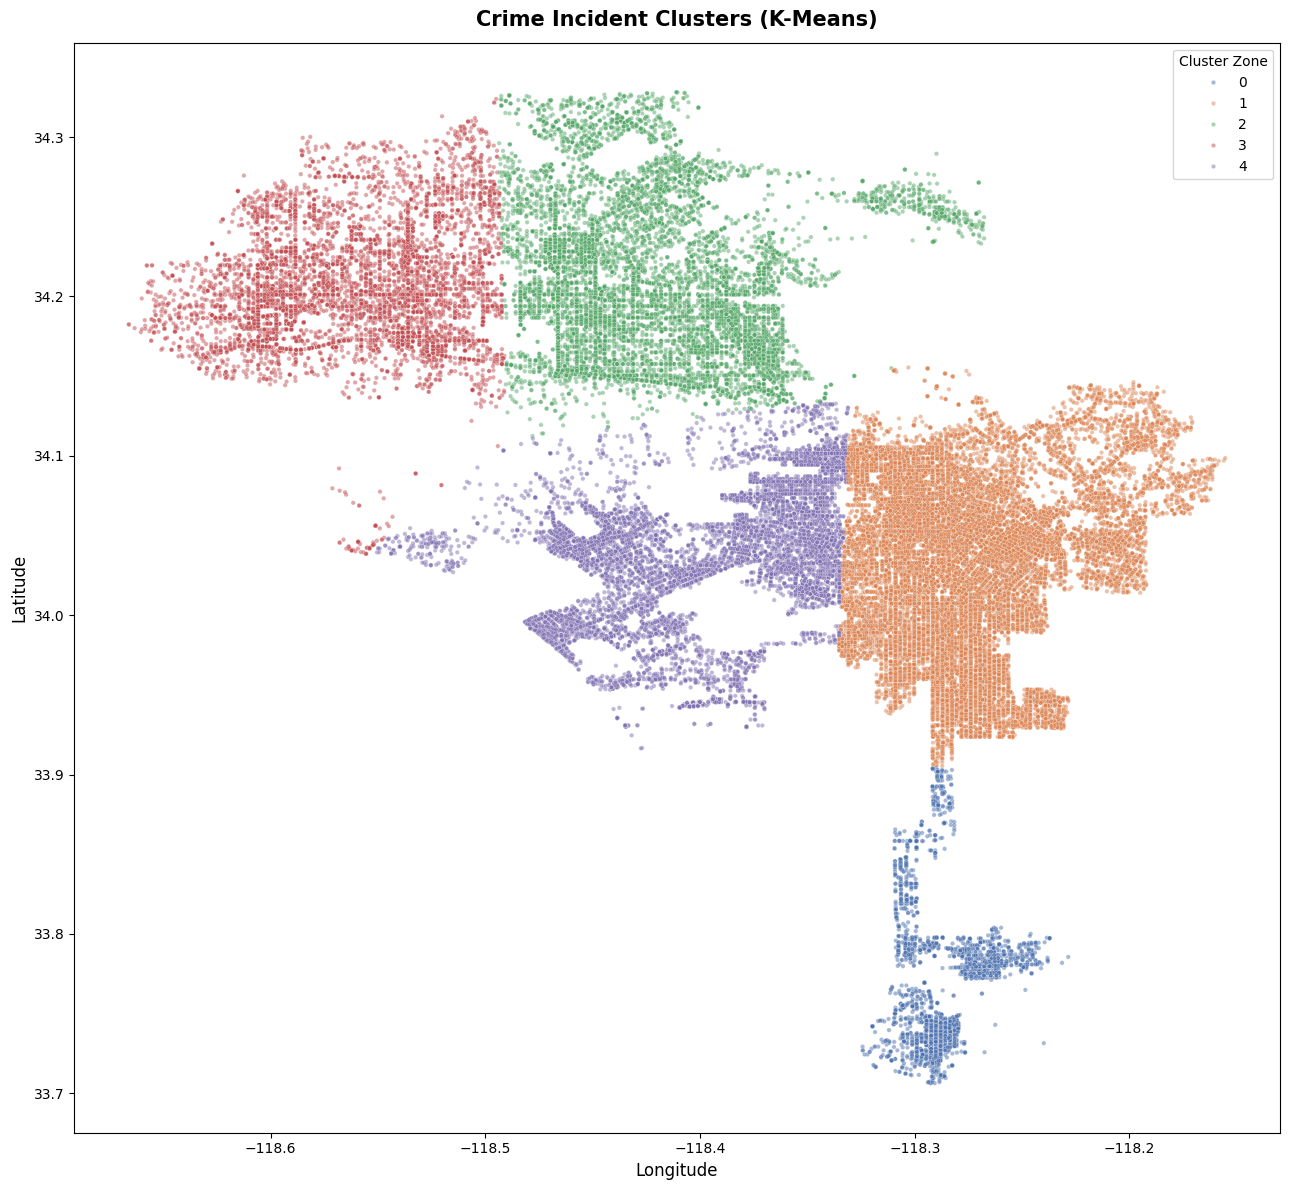

In [44]:
#3.0 K-Means (Model)

#3.1 Import necessary libraries
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#3.2 Train K-Means using the df prepared in 2.0
kmeans = KMeans(featuresCol="scaled_features", k=5, seed=67)
kmeans_model = kmeans.fit(df)

#3.3 Assign cluster labels to each row
predictions = kmeans_model.transform(df)

#3.4 Print Inertia to see how tight the clusters are (lower = better)
print(f"Inertia : {kmeans_model.summary.trainingCost:.2f}")
print("\n Cluster Centers:")
for i, center in enumerate(kmeans_model.clusterCenters()):
  print(f"Cluster {i}: {center}")

#3.5 Convert 10% sample to Pandas for plotting (downsize para di magcrash)
plot_df = (
    predictions
    .select("LAT","LON", "prediction")
    .sample(fraction=0.1, seed=67)
    .toPandas()
)

#3.6 Visualize the clusters on a scatter plot
plt.figure(figsize=(13, 12))
sns.scatterplot(
    data=plot_df,
    x="LON", y="LAT",
    hue="prediction",
    palette="deep",
    s=10, alpha=0.5,
    legend="full"
)

plt.title("Crime Incident Clusters (K-Means)",
          fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(title="Cluster Zone", loc="upper right")
plt.tight_layout()
plt.show()



<h3> <b>4.0 Data Preparation for Linear Regression </b> </h3>


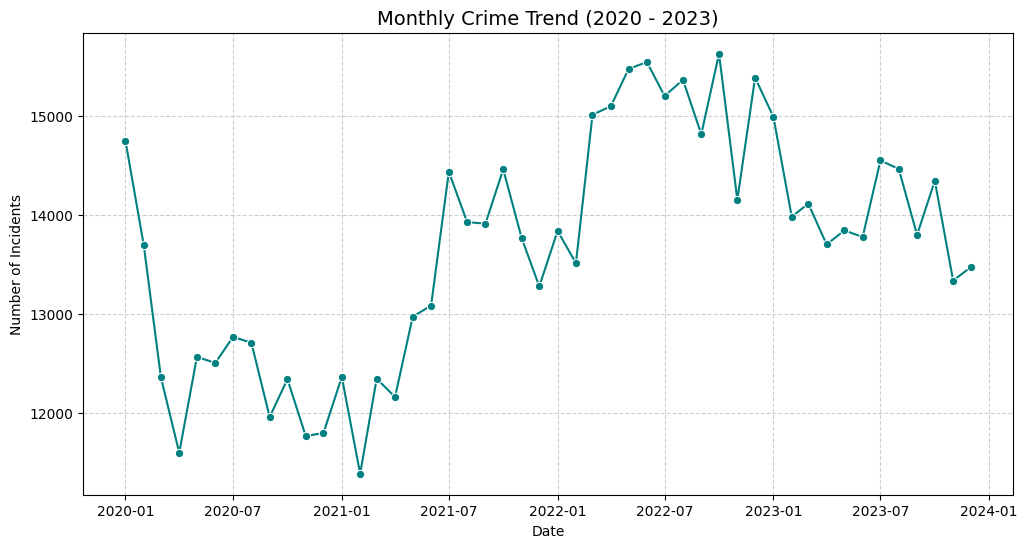

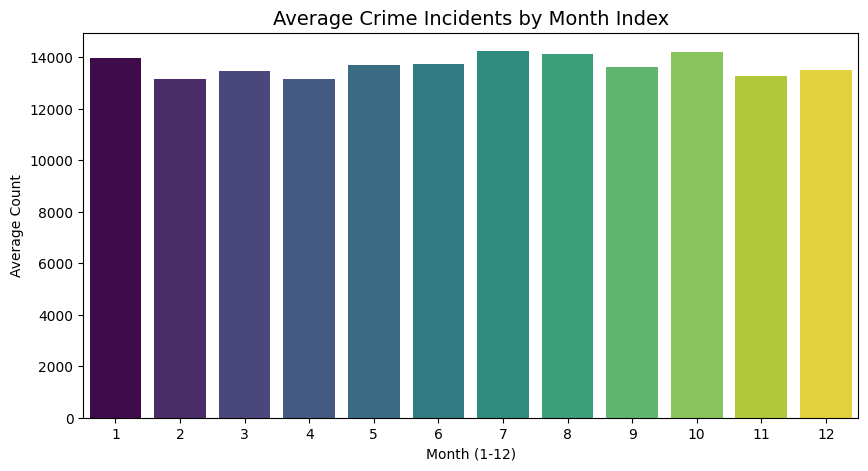

Data saved successfully to /content/drive/MyDrive/BIGD/monthly_crime_counts.csv


In [45]:
#4.0 Data Preparation for Linear Regression

#4.1 Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql import SparkSession

#4.2 Load the clean parquet file
df_lr = spark.read.parquet("/content/drive/MyDrive/BIGD/preprocessed1_femb.parquet")

# 4.2.1 Extract Year and Month if they don't exist
if "year" not in df_lr.columns or "month" not in df_lr.columns:
    df_lr = df_lr.withColumn("year", F.year("DATETIME_OCC")) \
                 .withColumn("month", F.month("DATETIME_OCC"))

#4.3 Aggregate crime counts by year and month
monthly_counts = (
    df_lr.groupBy("year", "month")
    .count()
    .orderBy("year", "month")
)

#4.4 Convert aggregated results to Pandas
pandas_counts = monthly_counts.toPandas()

#4.5 Build a proper date column from year and month columns
pandas_counts['Date'] = pd.to_datetime(pandas_counts[['year', 'month']].assign(DAY=1))
# Sort by date to ensure proper trend plotting
pandas_counts = pandas_counts.sort_values('Date')
pandas_counts = pandas_counts[pandas_counts['Date'] < '2024-01-01']

#4.6 Plot the raw monthly crime trend as a line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=pandas_counts, x='Date', y='count', marker='o', color='teal')
plt.title("Monthly Crime Trend (2020 - 2023)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Incidents")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#4.7 Plot the average crime count per month as a bar chart
avg_monthly = pandas_counts.groupby('month')['count'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_monthly, x='month', y='count', palette='viridis', hue='month', legend=False)
plt.title("Average Crime Incidents by Month Index", fontsize=14)
plt.xlabel("Month (1-12)")
plt.ylabel("Average Count")
plt.show()

#4.8 Save into as CSV to Google Drive
pandas_counts.to_csv("/content/drive/MyDrive/BIGD/monthly_crime_counts.csv", index=False)
print("Data saved successfully to /content/drive/MyDrive/BIGD/monthly_crime_counts.csv")

<h3> <b>5.0 Linear Regression (Model)</h3> </b>

Regression Slope: 48.92 crimes per month



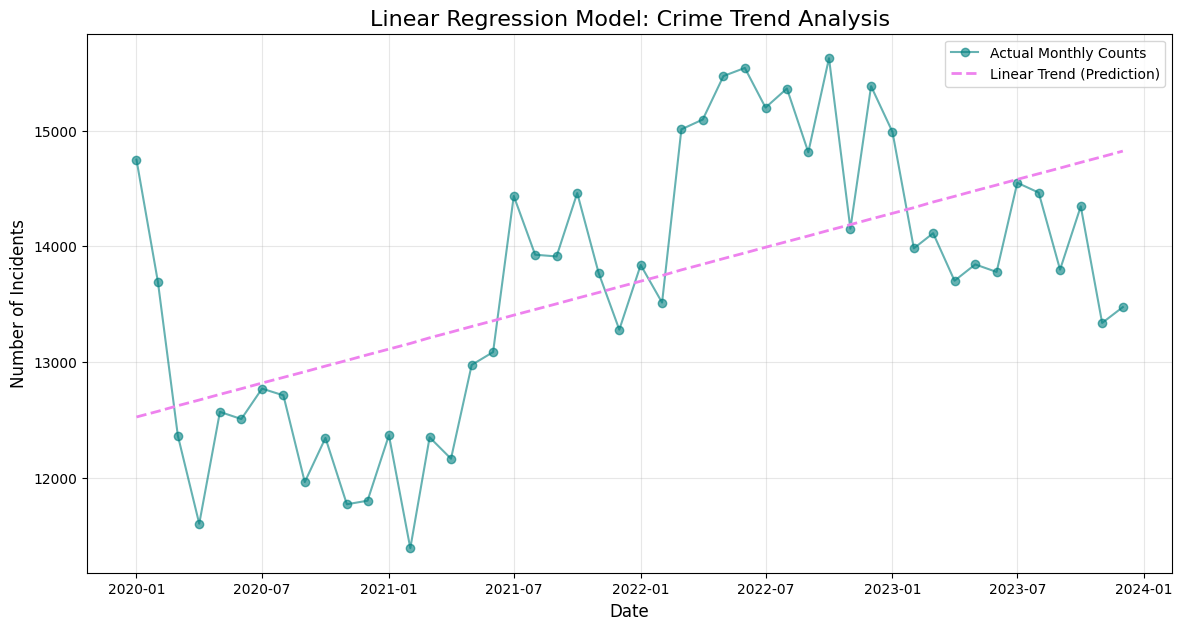

In [46]:
#5.0 Linear Regression (Model)

#5.1 Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#5.2 Load CSV saved by Member 3 from Google Drive
df_regression = pd.read_csv("/content/drive/MyDrive/BIGD/monthly_crime_counts.csv")

#5.3 Convert dates into a numeric time index
# Ensuring the data is sorted chronologically
df_regression['Date'] = pd.to_datetime(df_regression['Date'])
# Numeric time index (Jan 2020 = 0, Feb 2020 = 1, etc.)
df_regression['time_index'] = np.arange(len(df_regression))
# Reshape for Scikit-Learn to set up y = mX + b equation
X = df_regression[['time_index']].values
y = df_regression['count'].values

#5.4 Train the Linear Regression model on the monthly crime counts
model = LinearRegression()
model.fit(X, y)

#5.5 Generate predictions from the model
df_regression['trend_line'] = model.predict(X)
print(f"Regression Slope: {model.coef_[0]:.2f} crimes per month\n")

#5.6 Plot the trend line over the actual monthly counts
plt.figure(figsize=(14, 7))
# Actual historical data
plt.plot(df_regression['Date'],
          df_regression['count'],
          marker='o', color='teal',
          label='Actual Monthly Counts',
          alpha=0.6)
# Regression trend line
plt.plot(df_regression['Date'],
         df_regression['trend_line'],
         color='violet',
         linestyle='--',
         linewidth=2,
         label='Linear Trend (Prediction)')
plt.title("Linear Regression Model: Crime Trend Analysis", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()